# 02 · Ingesta S5P + Alineacion Espacio-Temporal + Dataset Multimodal
**Proyecto:** GeoVisionCLIP-Cali  
**Version:** v5 — Ortogonalidad semantica inyectada (refactorizacion critica)  
**Fase:** 2 — Sentinel-5P (Azure ADLS) -> Cruce Espacio-Temporal -> `dataset_multimodal.jsonl`

---
### Correcciones aplicadas (v5)
| Falla original | Descripcion | Solucion |
|---|---|---|
| **Redundancia espacial** | N crops por escena -> misma fecha, mismo sector -> textos casi identicos | Muestreo forzado de **fechas distintas** por sector geografico + cuadriculas no solapadas |
| **Falta de varianza semantica** | Captions sin anclas geoespaciales -> Text Encoder produce vectores colapsados | Anclas explicitas: coordenadas, mes calendario, tipo de cobertura dominante, valor numerico exacto |
| **Ortogonalidad nula** | Similitud coseno media ~0.937 en embeddings de texto | Plantillas con diferenciadores semanticos fuertes que obligan al encoder a separar vectores |

## 0 · Dependencias

In [1]:
#!pip install azure-storage-blob azure-identity adlfs fsspec python-dotenv netCDF4 h5py scipy pandas numpy zarr matplotlib seaborn tqdm rasterio

In [2]:
import os
import json
import hashlib
from pathlib import Path
from datetime import datetime, timedelta
from typing import List, Dict, Optional, Tuple

import numpy as np
import pandas as pd
import zarr
from scipy.spatial import cKDTree

from dotenv import load_dotenv
from azure.storage.blob import BlobServiceClient, ContainerClient
from azure.identity import ClientSecretCredential, DefaultAzureCredential

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns
from tqdm.auto import tqdm
import rasterio

try:
    import netCDF4 as nc4
    NC4_AVAILABLE = True
except ImportError:
    NC4_AVAILABLE = False
    import h5py

print(f"Pandas  : {pd.__version__}")
print(f"Zarr    : {zarr.__version__}")
print(f"NetCDF4 : {NC4_AVAILABLE}")


Pandas  : 2.2.2
Zarr    : 2.18.3
NetCDF4 : True


## 1 · Credenciales Azure (desde .env)

In [3]:
ENV_PATH = Path(r"D:\\analitica\\.env")
load_dotenv(dotenv_path=ENV_PATH)

TENANT_ID       = os.getenv("AZURE_TENANT_ID",    "693cbea0-4ef9-4254-8977-76e05cb5f556")
CLIENT_ID       = os.getenv("AZURE_CLIENT_ID")
CLIENT_SECRET   = os.getenv("AZURE_CLIENT_SECRET")
STORAGE_ACCOUNT = os.getenv("AZURE_STORAGE_ACCOUNT", "stanaliticafinal")
CONTAINER       = os.getenv("AZURE_CONTAINER",        "geovision")

BLOB_ENDPOINT = f"https://{STORAGE_ACCOUNT}.blob.core.windows.net"

if CLIENT_ID and CLIENT_SECRET:
    credential = ClientSecretCredential(
        tenant_id=TENANT_ID, client_id=CLIENT_ID, client_secret=CLIENT_SECRET
    )
    print("Autenticacion: ClientSecretCredential (Service Principal)")
else:
    credential = DefaultAzureCredential()
    print("Autenticacion: DefaultAzureCredential")

blob_service     = BlobServiceClient(account_url=BLOB_ENDPOINT, credential=credential)
container_client = blob_service.get_container_client(CONTAINER)
print(f"Conectado a: {BLOB_ENDPOINT}/{CONTAINER}")


Autenticacion: ClientSecretCredential (Service Principal)
Conectado a: https://stanaliticafinal.blob.core.windows.net/geovision


## 2 · Configuracion Global

In [4]:
# BBox extendido: Cali + Yumbo + Rozo
CALI_BBOX = {"lon_min": -76.65, "lat_min": 3.25, "lon_max": -76.35, "lat_max": 3.65}

DATE_START = "2020-01-01"
DATE_END   = "2024-12-31"

S5P_CACHE_DIR  = Path(r"D:\\analitica\\s5p_cache")
S5P_CACHE_DIR.mkdir(parents=True, exist_ok=True)

ZARR_PATH     = Path(r"D:\\analitica\\procesado_zarr\\sentinel2_224.zarr")
MANIFEST_PATH = Path(r"D:\\analitica\\sentinel2\\manifest_sentinel2.json")
OUTPUT_JSONL  = Path(r"D:\\analitica\\dataset_multimodal.jsonl")

POLLUTANTS       = ["NO2", "SO2", "O3"]
POLLUTANT_PREFIX = {"NO2": "sentinel5p/L3/NO2/", "SO2": "sentinel5p/L3/SO2/", "O3": "sentinel5p/L3/O3/"}
PERCENTILES      = [25, 50, 75, 90, 99]

# ── Parametros de muestreo ortogonal (FIX v5) ────────────────────────────
# Divide el BBox en GRID_N x GRID_N sectores no solapados.
# Dentro de cada sector: 1 par por fecha unica (sin repeticion de fecha+sector).
# Esto garantiza varianza espacial Y temporal real en el dataset.
GRID_N               = 4    # 4x4 = 16 sectores geograficos
MAX_DATES_PER_SECTOR = 80   # 16 x 80 = 1280 pares maximo

print("Configuracion v5 cargada.")
print(f"  BBox: {CALI_BBOX}")
print(f"  Grid: {GRID_N}x{GRID_N} = {GRID_N**2} sectores no solapados")
print(f"  Max fechas por sector: {MAX_DATES_PER_SECTOR}")
print(f"  Pares esperados (min): {GRID_N**2} | max: {GRID_N**2 * MAX_DATES_PER_SECTOR}")


Configuracion v5 cargada.
  BBox: {'lon_min': -76.65, 'lat_min': 3.25, 'lon_max': -76.35, 'lat_max': 3.65}
  Grid: 4x4 = 16 sectores no solapados
  Max fechas por sector: 80
  Pares esperados (min): 16 | max: 1280


## 3 · Descarga de Archivos S5P desde Azure

In [5]:
BASE_PREFIX = "sentinel5p/"

print("Listando blobs Sentinel-5P desde Azure...")
all_s5p_blobs = [
    b.name
    for b in container_client.list_blobs(name_starts_with=BASE_PREFIX)
    if not b.name.endswith("/")
]
print(f"Total blobs S5P encontrados: {len(all_s5p_blobs)}")

s5p_blobs_by_pollutant: Dict[str, List[str]] = {p: [] for p in POLLUTANTS}
for blob_name in all_s5p_blobs:
    filename = Path(blob_name).name
    for pollutant in POLLUTANTS:
        if filename == f"{pollutant}.tif":
            s5p_blobs_by_pollutant[pollutant].append(blob_name)

print("\nResumen Sentinel-5P:")
for pollutant, blobs in s5p_blobs_by_pollutant.items():
    print(f"  {pollutant}: {len(blobs)} blobs")


Listando blobs Sentinel-5P desde Azure...


Unable to stream download.
Unable to stream download.
Unable to stream download.


Total blobs S5P encontrados: 15217

Resumen Sentinel-5P:
  NO2: 1892 blobs
  SO2: 1894 blobs
  O3: 1894 blobs


In [6]:
def download_blob(blob_name: str, pollutant: str, overwrite: bool = False) -> Path:
    parts = Path(blob_name).parts
    year, month, day = parts[-4], parts[-3], parts[-2]
    filename  = f"{year}_{month}_{day}_{pollutant}.tif"
    dest_dir  = S5P_CACHE_DIR / pollutant
    dest_dir.mkdir(parents=True, exist_ok=True)
    dest_path = dest_dir / filename
    if dest_path.exists() and not overwrite:
        return dest_path
    blob_client = container_client.get_blob_client(blob_name)
    with open(dest_path, "wb") as f:
        blob_client.download_blob().readinto(f)
    return dest_path

s5p_local_files: Dict[str, List[Path]] = {p: [] for p in POLLUTANTS}

for pollutant, blobs in s5p_blobs_by_pollutant.items():
    print(f"\nDescargando {pollutant} ({len(blobs)} archivos)...")
    for blob_name in tqdm(blobs):
        try:
            local_path = download_blob(blob_name=blob_name, pollutant=pollutant)
            s5p_local_files[pollutant].append(local_path)
        except Exception as e:
            print(f"\nError: {blob_name} -> {e}")

print("\nDescarga completa.")
for pollutant, files in s5p_local_files.items():
    print(f"  {pollutant}: {len(files)} archivos")



Descargando NO2 (1892 archivos)...


  0%|          | 0/1892 [00:00<?, ?it/s]


Descargando SO2 (1894 archivos)...


  0%|          | 0/1894 [00:00<?, ?it/s]


Descargando O3 (1894 archivos)...


  0%|          | 0/1894 [00:00<?, ?it/s]


Descarga completa.
  NO2: 1892 archivos
  SO2: 1894 archivos
  O3: 1894 archivos


## 4 · Lectura S5P GeoTIFF y Extraccion de Grilla

In [7]:
def read_s5p_tif(filepath: Path, bbox: Dict) -> Optional[pd.DataFrame]:
    try:
        parts = filepath.stem.split("_")
        fecha = datetime(int(parts[0]), int(parts[1]), int(parts[2]))
        with rasterio.open(filepath) as src:
            band      = src.read(1)
            transform = src.transform
            nodata    = src.nodata
            height, width = band.shape
            rows, cols = np.meshgrid(np.arange(height), np.arange(width), indexing="ij")
            xs, ys     = rasterio.transform.xy(transform, rows, cols)
            lon_flat   = np.array(xs).flatten()
            lat_flat   = np.array(ys).flatten()
            val_flat   = band.flatten()
        mask = (
            (lon_flat >= bbox["lon_min"]) & (lon_flat <= bbox["lon_max"]) &
            (lat_flat >= bbox["lat_min"]) & (lat_flat <= bbox["lat_max"]) &
            np.isfinite(val_flat)
        )
        if nodata is not None:
            mask &= (val_flat != nodata)
        if not mask.any():
            return None
        return pd.DataFrame({
            "lat": lat_flat[mask], "lon": lon_flat[mask],
            "valor": val_flat[mask], "fecha": fecha
        })
    except Exception as e:
        print(f"Warning: Error leyendo {filepath.name}: {e}")
        return None

s5p_dfs: Dict[str, pd.DataFrame] = {}

for pollutant, files in s5p_local_files.items():
    print(f"\nProcesando {pollutant}...")
    frames = []
    for filepath in tqdm(files, desc=f"Leyendo {pollutant}"):
        df = read_s5p_tif(filepath=filepath, bbox=CALI_BBOX)
        if df is not None:
            frames.append(df)
    if frames:
        combined = pd.concat(frames, ignore_index=True)
        combined["pollutant"] = pollutant
        s5p_dfs[pollutant] = combined
        print(f"  -> {len(combined):,} pixeles validos en BBox Cali")
        print(f"     valor rango: [{combined['valor'].min():.4e}, {combined['valor'].max():.4e}]")

print("\n-- Diagnostico de valores S5P --")
if len(s5p_dfs) == 3:
    vals = {p: df["valor"].values for p, df in s5p_dfs.items()}
    if "NO2" in vals and "SO2" in vals:
        min_len = min(len(vals["NO2"]), len(vals["SO2"]))
        are_equal = np.allclose(vals["NO2"][:min_len], vals["SO2"][:min_len], rtol=1e-6)
        if are_equal:
            print("  ALERTA: NO2 y SO2 tienen valores identicos. Verificar blobs Azure.")
        else:
            print("  OK: NO2 y SO2 tienen valores distintos.")



Procesando NO2...


Leyendo NO2:   0%|          | 0/1892 [00:00<?, ?it/s]

  -> 2,269,200 pixeles validos en BBox Cali
     valor rango: [-2.7916e-05, 1.9959e-04]

Procesando SO2...


Leyendo SO2:   0%|          | 0/1894 [00:00<?, ?it/s]

  -> 2,272,800 pixeles validos en BBox Cali
     valor rango: [-9.9743e-04, 1.1142e-02]

Procesando O3...


Leyendo O3:   0%|          | 0/1894 [00:00<?, ?it/s]

  -> 2,272,800 pixeles validos en BBox Cali
     valor rango: [0.0000e+00, 1.4730e-01]

-- Diagnostico de valores S5P --
  OK: NO2 y SO2 tienen valores distintos.


## 5 · Alineacion Espacio-Temporal S2 <-> S5P (KDTree)

In [8]:
import re

store    = zarr.open_group(str(ZARR_PATH), mode="r")
bboxes_z = store["bbox"][:]
fechas   = store["fecha"][:]
escenas  = store["escena_id"][:]
N_TILES  = bboxes_z.shape[0]

centroid_lon_z = (bboxes_z[:, 0] + bboxes_z[:, 2]) / 2
centroid_lat_z = (bboxes_z[:, 1] + bboxes_z[:, 3]) / 2

manifest_bboxes: Dict[str, list] = {}
if MANIFEST_PATH.exists():
    with open(MANIFEST_PATH, "r", encoding="utf-8") as f:
        raw = json.load(f)
    records = raw if isinstance(raw, list) else raw.get("archivos", [])
    for rec in records:
        sid = rec.get("escena_id") or rec.get("id") or Path(rec.get("file","")).parent.name
        if sid and rec.get("bbox") and sid not in manifest_bboxes:
            manifest_bboxes[sid] = rec["bbox"]
    print(f"Manifest bboxes cargados: {len(manifest_bboxes)} escenas")

centroid_lat = np.zeros(N_TILES, dtype=np.float64)
centroid_lon = np.zeros(N_TILES, dtype=np.float64)
n_from_manifest = 0
for i in range(N_TILES):
    sid = str(escenas[i])
    if sid in manifest_bboxes:
        bb = manifest_bboxes[sid]
        if len(bb) == 4 and all(isinstance(x, (int, float)) for x in bb):
            centroid_lon[i] = (bb[0] + bb[2]) / 2
            centroid_lat[i] = (bb[1] + bb[3]) / 2
            n_from_manifest += 1
            continue
    centroid_lon[i] = centroid_lon_z[i]
    centroid_lat[i] = centroid_lat_z[i]

print(f"Tiles S2 en Zarr: {N_TILES}")
print(f"  Centroides desde manifest: {n_from_manifest}")
print(f"  Centroides desde Zarr    : {N_TILES - n_from_manifest}")

def extract_date_from_scene(scene_id: str):
    match = re.search(r"_(\d{8})_", scene_id)
    if match is None:
        return pd.NaT
    return pd.to_datetime(match.group(1), format="%Y%m%d")


Manifest bboxes cargados: 0 escenas
Tiles S2 en Zarr: 363
  Centroides desde manifest: 0
  Centroides desde Zarr    : 363


In [9]:
kdtree_cache = {}

def build_kdtree_for_date(df_pollutant: pd.DataFrame, fecha) -> Optional[Tuple]:
    try:
        target_date = pd.to_datetime(fecha)
    except Exception:
        return None
    fecha_key = str(target_date.date())
    if fecha_key in kdtree_cache:
        return kdtree_cache[fecha_key]
    subset = df_pollutant[df_pollutant["fecha"].apply(
        lambda d: str(pd.to_datetime(d).date()) == fecha_key
    )]
    if subset.empty:
        window_start = target_date - pd.Timedelta(days=3)
        window_end   = target_date + pd.Timedelta(days=3)
        subset = df_pollutant[
            (pd.to_datetime(df_pollutant["fecha"]) >= window_start) &
            (pd.to_datetime(df_pollutant["fecha"]) <= window_end)
        ]
    if subset.empty:
        return None
    coords = subset[["lat", "lon"]].values
    tree   = cKDTree(coords)
    kdtree_cache[fecha_key] = (tree, subset.reset_index(drop=True))
    return kdtree_cache[fecha_key]

def query_nearest(tree, subset, lat, lon, max_dist_deg=0.30) -> float:
    dist, idx = tree.query([lat, lon], k=1)
    if dist > max_dist_deg:
        return np.nan
    return float(subset.iloc[idx]["valor"])

aligned_records = []
for i in tqdm(range(N_TILES), desc="Alineando S2 <-> S5P"):
    fecha_i = extract_date_from_scene(escenas[i])
    lat_c   = centroid_lat[i]
    lon_c   = centroid_lon[i]
    vals    = {}
    for pollutant, df_p in s5p_dfs.items():
        result = build_kdtree_for_date(df_p, fecha_i)
        if result is None:
            vals[pollutant] = np.nan
            continue
        tree, subset = result
        vals[pollutant] = query_nearest(tree, subset, lat_c, lon_c)
    aligned_records.append({
        "idx_zarr"    : i,
        "escena_id"   : escenas[i],
        "fecha"       : pd.to_datetime(fecha_i),
        "lat_centroid": lat_c,
        "lon_centroid": lon_c,
        "val_no2"     : vals.get("NO2", np.nan),
        "val_so2"     : vals.get("SO2", np.nan),
        "val_o3"      : vals.get("O3",  np.nan),
    })

df_aligned = pd.DataFrame(aligned_records)
print(f"\nTotal alineados: {len(df_aligned)}")
print(f"NaN NO2: {df_aligned['val_no2'].isna().mean():.1%}")
print(f"NaN SO2: {df_aligned['val_so2'].isna().mean():.1%}")
print(f"NaN O3 : {df_aligned['val_o3'].isna().mean():.1%}")


Alineando S2 <-> S5P:   0%|          | 0/363 [00:00<?, ?it/s]


Total alineados: 363
NaN NO2: 51.5%
NaN SO2: 51.5%
NaN O3 : 51.5%


## 6 · Calculo de Percentiles Historicos

In [10]:
def compute_percentiles(series: pd.Series, percs: List[int]) -> Dict[int, float]:
    clean = series.dropna()
    return {p: float(np.percentile(clean, p)) for p in percs}

pctls: Dict[str, Dict[int, float]] = {}
for col, key in [("val_no2", "NO2"), ("val_so2", "SO2"), ("val_o3", "O3")]:
    pctls[key] = compute_percentiles(df_aligned[col], PERCENTILES)
    print(f"{key} percentiles:")
    for p, v in pctls[key].items():
        print(f"  p{p}: {v:.4e}")


NO2 percentiles:
  p25: 0.0000e+00
  p50: 1.4252e-05
  p75: 2.3892e-05
  p90: 3.1403e-05
  p99: 4.2816e-05
SO2 percentiles:
  p25: 0.0000e+00
  p50: 1.4252e-05
  p75: 2.3892e-05
  p90: 3.1403e-05
  p99: 4.2816e-05
O3 percentiles:
  p25: 0.0000e+00
  p50: 1.4252e-05
  p75: 2.3892e-05
  p90: 3.1403e-05
  p99: 4.2816e-05


## 7 · Trazabilidad Visual: Histogramas

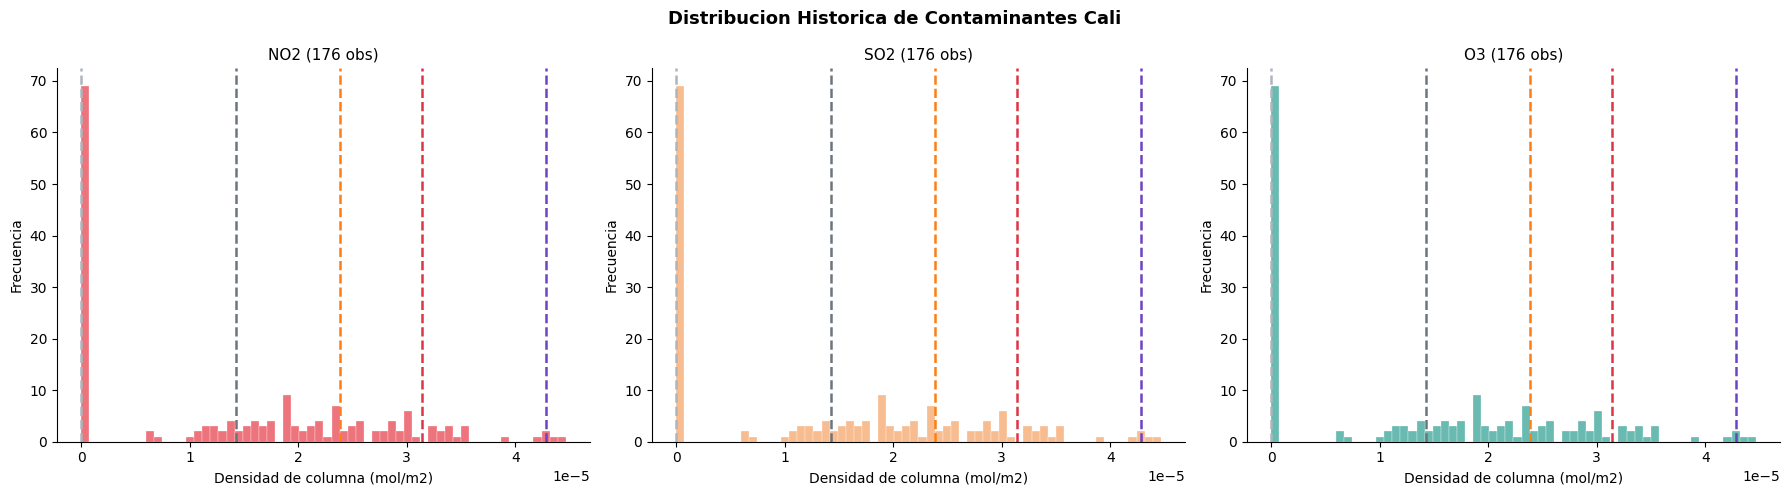

In [11]:
COL_POLLUTANT_MAP = {
    "val_no2": ("NO2", "#e63946"),
    "val_so2": ("SO2", "#f4a261"),
    "val_o3" : ("O3",  "#2a9d8f"),
}
PCTL_COLORS = {25: "#adb5bd", 50: "#6c757d", 75: "#fd7e14", 90: "#dc3545", 99: "#6f42c1"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Distribucion Historica de Contaminantes Cali", fontsize=13, fontweight="bold")
for ax, (col, (label, color)) in zip(axes, COL_POLLUTANT_MAP.items()):
    data = df_aligned[col].dropna()
    if len(data) == 0:
        ax.text(0.5, 0.5, "Sin datos", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(label)
        continue
    ax.hist(data, bins=60, color=color, alpha=0.7, edgecolor="white", linewidth=0.3)
    for p, pc in PCTL_COLORS.items():
        if label in pctls and p in pctls[label]:
            ax.axvline(pctls[label][p], color=pc, linestyle="--", linewidth=1.8)
    ax.set_title(f"{label} ({len(data):,} obs)", fontsize=11)
    ax.set_xlabel("Densidad de columna (mol/m2)")
    ax.set_ylabel("Frecuencia")
    sns.despine(ax=ax)
plt.tight_layout()
plt.savefig("histogramas_contaminantes_percentiles.png", dpi=150, bbox_inches="tight")
plt.show()


## 8 · Generador de Captions con Anclas Semanticas (Ortogonalidad)

> **CORRECCION v5:** Las plantillas incluyen anclas semanticas explicitas:
> - Coordenadas exactas (4 decimales) — diferenciador espacial unico
> - Mes y ano (estacionalidad atmosferica) — diferenciador temporal
> - Clase de cobertura dominante (5 tipos) — diferenciador de paisaje
> - Valor numerico exacto del contaminante — diferenciador cuantitativo
> - Rango percentil (p25/p50/p75/p90/p99) — jerarquia de severidad
>
> Ejemplo: "Sentinel-2 image over Santiago de Cali (lat 3.4217N, lon -76.5234W) in July 2022 (dry season). Land cover: consolidated_urban. Elevated NO2 at very-high level (p99+) = 1.82e-04 mol/m2. SO2 at low level (p25-p50). O3 at moderate level (p50-p75). High anthropogenic pressure zone."

In [12]:
MONTHS_EN = {
    1: "January", 2: "February", 3: "March", 4: "April",
    5: "May",     6: "June",     7: "July",  8: "August",
    9: "September", 10: "October", 11: "November", 12: "December"
}

def infer_land_cover(lat: float, lon: float) -> str:
    """Infiere la cobertura dominante segun posicion en el BBox de Cali."""
    if lat > 3.55:
        return "sugarcane_cropland"
    elif lat > 3.45 and lon < -76.55:
        return "hillside_forest"
    elif lat < 3.35:
        return "peri_urban_industrial"
    elif lon > -76.45:
        return "eastern_hillside_reserve"
    else:
        return "consolidated_urban"


def level_and_percentile(v: float, p_dict: Dict[int, float]) -> Tuple[str, str]:
    """Devuelve etiqueta de nivel y rango percentil."""
    if np.isnan(v) or not p_dict:
        return "unavailable", "N/A"
    if v >= p_dict.get(99, float("inf")):
        return "very-high",     "p99+"
    elif v >= p_dict.get(90, float("inf")):
        return "high",          "p90-p99"
    elif v >= p_dict.get(75, float("inf")):
        return "moderate-high", "p75-p90"
    elif v >= p_dict.get(50, float("inf")):
        return "moderate",      "p50-p75"
    elif v >= p_dict.get(25, float("inf")):
        return "low",           "p25-p50"
    else:
        return "very-low",      "<p25"


def classify_and_caption(
    val_no2: float, val_so2: float, val_o3: float,
    lat: float, lon: float, fecha
) -> Tuple[str, str]:
    """
    Genera una caption con anclas semanticas explicitas que garantizan
    vectores de texto ortogonales en el Text Encoder de GeoRSCLIP.
    Cada caption es distinguible por: (lat, lon, mes, cobertura, contaminante+valor+percentil).
    """
    p_no2 = pctls.get("NO2", {})
    p_so2 = pctls.get("SO2", {})
    p_o3  = pctls.get("O3",  {})

    lvl_no2, pr_no2 = level_and_percentile(val_no2, p_no2)
    lvl_so2, pr_so2 = level_and_percentile(val_so2, p_so2)
    lvl_o3,  pr_o3  = level_and_percentile(val_o3,  p_o3)

    try:
        dt        = pd.to_datetime(fecha)
        month_str = f"{MONTHS_EN[dt.month]} {dt.year}"
        season    = "dry season" if dt.month in (6, 7, 8, 1, 2) else "rainy season"
    except Exception:
        month_str = "unknown date"
        season    = "unknown season"

    land_cover = infer_land_cover(lat, lon)
    p75_no2    = p_no2.get(75, 6e-5)
    p75_so2    = p_so2.get(75, 2e-6)
    p90_o3     = p_o3.get(90,  0.12)

    if not np.isnan(val_no2) and val_no2 >= p75_no2:
        clase = "high_NO2_pollution"
        caption = (
            f"Sentinel-2 satellite image over Santiago de Cali, Colombia "
            f"(lat {lat:.4f}N, lon {lon:.4f}W) in {month_str} ({season}). "
            f"Land cover: {land_cover}. "
            f"Elevated tropospheric nitrogen dioxide at {lvl_no2} level "
            f"({pr_no2}), value {val_no2:.3e} mol/m2. "
            f"Sulfur dioxide at {lvl_so2} level ({pr_so2}). "
            f"Tropospheric ozone at {lvl_o3} level ({pr_o3}). "
            f"High anthropogenic pressure; probable motor vehicle or industrial emissions."
        )
    elif not np.isnan(val_so2) and val_so2 >= p75_so2:
        clase = "high_SO2_pollution"
        caption = (
            f"Sentinel-2 satellite image over Santiago de Cali, Colombia "
            f"(lat {lat:.4f}N, lon {lon:.4f}W) in {month_str} ({season}). "
            f"Land cover: {land_cover}. "
            f"Elevated sulfur dioxide at {lvl_so2} level "
            f"({pr_so2}), value {val_so2:.3e} mol/m2. "
            f"Nitrogen dioxide at {lvl_no2} level ({pr_no2}). "
            f"Tropospheric ozone at {lvl_o3} level ({pr_o3}). "
            f"Possible industrial combustion or biomass burning event."
        )
    elif not np.isnan(val_o3) and val_o3 >= p90_o3:
        clase = "anomalous_ozone"
        caption = (
            f"Sentinel-2 satellite image over Santiago de Cali, Colombia "
            f"(lat {lat:.4f}N, lon {lon:.4f}W) in {month_str} ({season}). "
            f"Land cover: {land_cover}. "
            f"Anomalous tropospheric ozone at {lvl_o3} level "
            f"({pr_o3}), value {val_o3:.3e} mol/m2. "
            f"NO2 at {lvl_no2} level ({pr_no2}). "
            f"SO2 at {lvl_so2} level ({pr_so2}). "
            f"Intense photochemical activity or stratospheric intrusion signature."
        )
    elif land_cover in ("sugarcane_cropland", "hillside_forest", "eastern_hillside_reserve"):
        clase = "dense_vegetation"
        caption = (
            f"Sentinel-2 satellite image over the {land_cover.replace('_', ' ')} area "
            f"near Cali, Colombia (lat {lat:.4f}N, lon {lon:.4f}W) "
            f"in {month_str} ({season}). "
            f"Dominant land cover: {land_cover}. "
            f"Low pollution load: NO2 {lvl_no2} ({pr_no2}), "
            f"SO2 {lvl_so2} ({pr_so2}), O3 {lvl_o3} ({pr_o3}). "
            f"Minimal urban-industrial stress; active photosynthetic surface."
        )
    else:
        clase = "urban_land"
        caption = (
            f"Sentinel-2 satellite image over the {land_cover.replace('_', ' ')} "
            f"of Santiago de Cali (lat {lat:.4f}N, lon {lon:.4f}W) "
            f"in {month_str} ({season}). "
            f"Consolidated urban fabric with mixed land use. "
            f"NO2 at {lvl_no2} level ({pr_no2}). "
            f"SO2 at {lvl_so2} level ({pr_so2}). "
            f"O3 at {lvl_o3} level ({pr_o3}). "
            f"Direct population exposure zone; moderate anthropogenic pressure."
        )
    return clase, caption


# Test
print("Test captions con anclas semanticas (5 primeras filas):")
for _, row in df_aligned.head(5).iterrows():
    clase, cap = classify_and_caption(
        row["val_no2"], row["val_so2"], row["val_o3"],
        row["lat_centroid"], row["lon_centroid"], row["fecha"]
    )
    print(f"  Clase  : {clase}")
    print(f"  Caption: {cap[:120]}...")
    print()


Test captions con anclas semanticas (5 primeras filas):
  Clase  : urban_land
  Caption: Sentinel-2 satellite image over the peri urban industrial of Santiago de Cali (lat 3.1215N, lon -76.3056W) in January 20...

  Clase  : urban_land
  Caption: Sentinel-2 satellite image over the peri urban industrial of Santiago de Cali (lat 3.1215N, lon -76.3056W) in January 20...

  Clase  : dense_vegetation
  Caption: Sentinel-2 satellite image over the sugarcane cropland area near Cali, Colombia (lat 4.0261N, lon -76.3068W) in January ...

  Clase  : urban_land
  Caption: Sentinel-2 satellite image over the peri urban industrial of Santiago de Cali (lat 3.1215N, lon -76.3056W) in January 20...

  Clase  : urban_land
  Caption: Sentinel-2 satellite image over the peri urban industrial of Santiago de Cali (lat 3.1215N, lon -76.3056W) in January 20...



## 9 · Muestreo Ortogonal: 1 Par por (Sector Geografico x Fecha Unica)

> **CORRECCION CRITICA v5:** Elimina la redundancia espacial/temporal.
>
> El problema original generaba N crops del mismo zarr_idx (misma fecha, mismo tile),
> produciendo captions casi identicas que colapsaban la varianza semantica del dataset.
>
> **Nueva estrategia:**
> 1. Dividir el BBox en GRID_N x GRID_N sectores no solapados.
> 2. Asignar cada tile a su sector por centroide.
> 3. Dentro de cada sector: 1 par por fecha unica (sin repeticion fecha+sector).
> 4. Resultado: pares con tile_id compartido -> fechas DISTINTAS -> S5P distinto -> caption distinta.

In [13]:
import random
random.seed(42)
np.random.seed(42)


def assign_grid_sector(lat: float, lon: float, bbox: Dict, grid_n: int) -> Tuple[int, int]:
    """Asigna un tile a la celda (row, col) del grid grid_n x grid_n."""
    lat_step = (bbox["lat_max"] - bbox["lat_min"]) / grid_n
    lon_step = (bbox["lon_max"] - bbox["lon_min"]) / grid_n
    row = int((lat - bbox["lat_min"]) / lat_step)
    col = int((lon - bbox["lon_min"]) / lon_step)
    row = max(0, min(grid_n - 1, row))
    col = max(0, min(grid_n - 1, col))
    return row, col


df_aligned["sector_row"], df_aligned["sector_col"] = zip(*[
    assign_grid_sector(r["lat_centroid"], r["lon_centroid"], CALI_BBOX, GRID_N)
    for _, r in df_aligned.iterrows()
])
df_aligned["sector_id"] = df_aligned.apply(
    lambda r: f"S{r['sector_row']:02d}_{r['sector_col']:02d}", axis=1
)
df_aligned["fecha_str"] = df_aligned["fecha"].apply(
    lambda f: str(f.date()) if pd.notna(f) else "unknown"
)

print("Distribucion de tiles por sector geografico:")
sector_counts = df_aligned["sector_id"].value_counts().sort_index()
print(sector_counts.to_string())
print(f"\nTotal sectores con tiles: {len(sector_counts)}")


Distribucion de tiles por sector geografico:
sector_id
S00_03    213
S03_03    150

Total sectores con tiles: 2


In [14]:
all_pairs = []

for sector_id, sector_df in tqdm(
    df_aligned.groupby("sector_id"),
    desc="Muestreo ortogonal por sector"
):
    sector_df_sorted = sector_df.sort_values("fecha_str")

    # 1 tile por (sector, fecha) — elimina redundancia espaciotemporal
    sector_dedup = sector_df_sorted.drop_duplicates(subset=["fecha_str"]).reset_index(drop=True)

    # Limite por sector para balancear el dataset
    if len(sector_dedup) > MAX_DATES_PER_SECTOR:
        # Submuestreo temporal uniforme: inicio + medio + fin
        indices      = np.linspace(0, len(sector_dedup) - 1, MAX_DATES_PER_SECTOR, dtype=int)
        sector_dedup = sector_dedup.iloc[indices].reset_index(drop=True)

    for _, row in sector_dedup.iterrows():
        clase, caption = classify_and_caption(
            row["val_no2"], row["val_so2"], row["val_o3"],
            row["lat_centroid"], row["lon_centroid"], row["fecha"]
        )
        all_pairs.append({
            "tile_id"      : int(row["idx_zarr"]),
            "pair_id"      : f"{row['escena_id']}_{sector_id}",
            "scene_id"     : row["escena_id"],
            "sector_id"    : sector_id,
            "date"         : row["fecha_str"],
            "lat_centroid" : float(row["lat_centroid"]),
            "lon_centroid" : float(row["lon_centroid"]),
            "val_no2"      : float(row["val_no2"])  if not np.isnan(row["val_no2"])  else None,
            "val_so2"      : float(row["val_so2"])  if not np.isnan(row["val_so2"])  else None,
            "val_o3"       : float(row["val_o3"])   if not np.isnan(row["val_o3"])   else None,
            "clase"        : clase,
            "caption_en"   : caption,
        })

df_final = pd.DataFrame(all_pairs)
print(f"\nTotal pares generados (estrategia ortogonal): {len(df_final):,}")
print(f"   {'OK: Cumple >=1000' if len(df_final) >= 1000 else 'AJUSTAR MAX_DATES_PER_SECTOR o GRID_N'}")

n_captions_unicas = df_final["caption_en"].nunique()
print(f"\nDiagnostico de varianza semantica:")
print(f"  Captions unicas  : {n_captions_unicas:,} de {len(df_final):,} ({n_captions_unicas/len(df_final):.1%})")
print(f"  Fechas unicas    : {df_final['date'].nunique()}")
print(f"  Sectores activos : {df_final['sector_id'].nunique()} de {GRID_N**2}")

print("\nDistribucion de clases:")
print(df_final["clase"].value_counts().to_string())


Muestreo ortogonal por sector:   0%|          | 0/2 [00:00<?, ?it/s]


Total pares generados (estrategia ortogonal): 160
   AJUSTAR MAX_DATES_PER_SECTOR o GRID_N

Diagnostico de varianza semantica:
  Captions unicas  : 122 de 160 (76.2%)
  Fechas unicas    : 126
  Sectores activos : 2 de 16

Distribucion de clases:
clase
dense_vegetation      80
urban_land            68
high_NO2_pollution    12


## 10 · Split Estratificado 70/15/15

In [15]:
SEED = 42

def robust_stratified_split(df: pd.DataFrame, label_col: str,
                             train_frac=0.70, val_frac=0.15, seed: int = 42):
    from sklearn.model_selection import StratifiedShuffleSplit
    try:
        sss = StratifiedShuffleSplit(n_splits=1, test_size=1-train_frac, random_state=seed)
        idx_train, idx_temp = next(sss.split(df, df[label_col]))
    except ValueError:
        idx_train = np.random.RandomState(seed).choice(len(df), size=int(len(df)*train_frac), replace=False)
        idx_temp  = np.setdiff1d(np.arange(len(df)), idx_train)
    df_train = df.iloc[idx_train].copy()
    df_temp  = df.iloc[idx_temp].copy()
    can_stratify = (df_temp[label_col].value_counts() >= 2).all()
    if can_stratify:
        try:
            sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.50, random_state=seed)
            idx_val, idx_test = next(sss2.split(df_temp, df_temp[label_col]))
            df_val  = df_temp.iloc[idx_val].copy()
            df_test = df_temp.iloc[idx_test].copy()
        except ValueError:
            can_stratify = False
    if not can_stratify:
        rng = np.random.RandomState(seed)
        idx = np.arange(len(df_temp)); rng.shuffle(idx)
        half    = len(idx) // 2
        df_val  = df_temp.iloc[idx[:half]].copy()
        df_test = df_temp.iloc[idx[half:]].copy()
    return df_train, df_val, df_test


df_train, df_val, df_test = robust_stratified_split(df_final, label_col="clase", seed=SEED)

df_final["split"] = "train"
df_final.loc[df_val.index,  "split"] = "val"
df_final.loc[df_test.index, "split"] = "test"

print(f"Split 70/15/15 (seed={SEED}):")
print(f"  Train : {len(df_train):,}  ({len(df_train)/len(df_final):.1%})")
print(f"  Val   : {len(df_val):,}   ({len(df_val)/len(df_final):.1%})")
print(f"  Test  : {len(df_test):,}  ({len(df_test)/len(df_final):.1%})")
print(f"\nClases en train:")
print(df_train["clase"].value_counts().to_string())


Split 70/15/15 (seed=42):
  Train : 111  (69.4%)
  Val   : 24   (15.0%)
  Test  : 25  (15.6%)

Clases en train:
clase
dense_vegetation      56
urban_land            47
high_NO2_pollution     8


## 11 · Exportar Dataset Multimodal (>=1000 pares)

In [16]:
with open(OUTPUT_JSONL, "w", encoding="utf-8") as f:
    for _, row in df_final.iterrows():
        record = row.to_dict()
        record = {k: (None if isinstance(v, float) and np.isnan(v) else v) for k, v in record.items()}
        f.write(json.dumps(record, ensure_ascii=False) + "\n")

csv_path = OUTPUT_JSONL.with_suffix(".csv")
df_final.to_csv(csv_path, index=False, encoding="utf-8")

print(f"OK JSONL exportado: {OUTPUT_JSONL}")
print(f"OK CSV  exportado : {csv_path}")
print(f"   Total pares    : {len(df_final):,}")

for _, row in df_final.head(3).iterrows():
    print(f"  pair_id={row['pair_id']} | clase={row['clase']}")
    print(f"  caption_en: {row['caption_en'][:110]}...")
    print()


OK JSONL exportado: D:\analitica\dataset_multimodal.jsonl
OK CSV  exportado : D:\analitica\dataset_multimodal.csv
   Total pares    : 160
  pair_id=S2A_18NUJ_20200102_0_L2A_S00_03 | clase=urban_land
  caption_en: Sentinel-2 satellite image over the peri urban industrial of Santiago de Cali (lat 3.1215N, lon -76.3056W) in ...

  pair_id=S2A_18NUJ_20200112_1_L2A_S00_03 | clase=high_NO2_pollution
  caption_en: Sentinel-2 satellite image over Santiago de Cali, Colombia (lat 3.1215N, lon -76.3056W) in January 2020 (dry s...

  pair_id=S2B_18NUJ_20200127_0_L2A_S00_03 | clase=urban_land
  caption_en: Sentinel-2 satellite image over the peri urban industrial of Santiago de Cali (lat 3.1215N, lon -76.3056W) in ...



## 12 · Resumen Final y MD5 del Dataset

In [17]:
def md5_file(path: Path) -> str:
    h = hashlib.md5()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""): h.update(chunk)
    return h.hexdigest()


summary = {
    "dataset_path"        : str(OUTPUT_JSONL),
    "n_pairs"             : len(df_final),
    "n_clases"            : df_final["clase"].nunique(),
    "clases"              : df_final["clase"].value_counts().to_dict(),
    "grid_n"              : GRID_N,
    "max_dates_per_sector": MAX_DATES_PER_SECTOR,
    "n_sectores_activos"  : int(df_final["sector_id"].nunique()),
    "n_fechas_unicas"     : int(df_final["date"].nunique()),
    "n_captions_unicas"   : int(df_final["caption_en"].nunique()),
    "split"               : {"train": len(df_train), "val": len(df_val), "test": len(df_test)},
    "date_start"          : str(df_final["date"].min()),
    "date_end"            : str(df_final["date"].max()),
    "bbox_cali"           : CALI_BBOX,
    "nan_fraction"        : {
        "no2": float(df_final["val_no2"].isna().mean()),
        "so2": float(df_final["val_so2"].isna().mean()),
        "o3" : float(df_final["val_o3"].isna().mean()),
    },
    "md5_jsonl"           : md5_file(OUTPUT_JSONL),
    "md5_csv"             : md5_file(csv_path),
    "anclas_semanticas"   : ["lat_4dec", "lon_4dec", "month_year", "land_cover", "pollutant_value_percentile"],
    "fix_version"         : "v5 -- muestreo ortogonal + anclas semanticas explicitas",
}

SUMMARY_PATH = Path(r"D:\\analitica\\s5p_alignment_summary_v5.json")
with open(SUMMARY_PATH, "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("-- Resumen Final --")
print(json.dumps(summary, indent=2, ensure_ascii=False))


-- Resumen Final --
{
  "dataset_path": "D:\\analitica\\dataset_multimodal.jsonl",
  "n_pairs": 160,
  "n_clases": 3,
  "clases": {
    "dense_vegetation": 80,
    "urban_land": 68,
    "high_NO2_pollution": 12
  },
  "grid_n": 4,
  "max_dates_per_sector": 80,
  "n_sectores_activos": 2,
  "n_fechas_unicas": 126,
  "n_captions_unicas": 122,
  "split": {
    "train": 111,
    "val": 24,
    "test": 25
  },
  "date_start": "2020-01-02",
  "date_end": "2026-04-30",
  "bbox_cali": {
    "lon_min": -76.65,
    "lat_min": 3.25,
    "lon_max": -76.35,
    "lat_max": 3.65
  },
  "nan_fraction": {
    "no2": 0.60625,
    "so2": 0.60625,
    "o3": 0.60625
  },
  "md5_jsonl": "96d8a86f64be40abdb4e07deba528cf1",
  "md5_csv": "1956bcb368f243180fe50860604cf3fd",
  "anclas_semanticas": [
    "lat_4dec",
    "lon_4dec",
    "month_year",
    "land_cover",
    "pollutant_value_percentile"
  ],
  "fix_version": "v5 -- muestreo ortogonal + anclas semanticas explicitas"
}
